# Four models: PCA + distances, PCA + dihedrals, tICA + distances, tICA + dihedrals

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import matplotlib.cm as cm
from deeptime.decomposition import TICA

data_folder = "./data/"

In [21]:
# set 1: distances
distances = np.loadtxt(data_folder + "hp35.mindists2", delimiter = " ", dtype = float)
print("Data shape", distances.shape) # [nm] nanometers
print("Data size (MB)", distances.nbytes / (10**6))

# set 2: dihedrals
#dihedrals = np.loadtxt(data_folder + "hp35.dihs.shifted", delimiter = " ", dtype = float)
#print(dihedrals.shape) # [radians] 

Data shape (1526041, 42)
Data size (MB) 512.749776


In [22]:
total_time_micros = 300
time_step_micros =  total_time_micros / distances.shape[0]
print("Time step (microseconds)", time_step_micros) # 2x10^-4 microseconds
print("Time step (nanoseconds)", time_step_micros * 10**3) # 0.2 nanoseconds
print("Time step (picoseconds)", time_step_micros * 10**6) # 200 picoseconds

Time step (microseconds) 0.00019658711659778472
Time step (nanoseconds) 0.19658711659778472
Time step (picoseconds) 196.58711659778473


## PCA vs tICA

In [37]:
def plot_free_energy_projection(dimred_traj, component_x, component_y, ax = None, axlabel = "PC", axtitle = None):

    if ax == None:
        fig, ax__ = plt.subplots(1, 1, figsize=(5, 4))
    else:
        ax__ = ax

    # Scatter plot
    ax__.scatter(
        dimred_traj[:, component_x],
        dimred_traj[:, component_y],
        s=0.01,
        alpha=0.3
    )

    ax__.set_xlabel(f"{axlabel}{component_x}")
    ax__.set_ylabel(f"{axlabel}{component_y}")


    # 2D histogram (Free energy)
    H, xedges, yedges = np.histogram2d(
        dimred_traj[:, component_x],
        dimred_traj[:, component_y],
        bins=100,
        density=True
    )
    mask = H > 0
    F = np.full_like(H, np.nan)
    F[mask] = -np.log(H[mask])
    F -= np.nanmin(F)

    im = ax__.imshow(
        F.T,
        origin="lower",
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        aspect="auto"
    )

    plt.colorbar(im, ax=ax__, label=r"$F/k_B T$")
    ax__.set_xlabel(f"{axlabel}{component_x}")
    ax__.set_ylabel(f"{axlabel}{component_y}")
    if axtitle is not None:
        ax__.set_title(f"{axtitle}")

    return ax__

In [39]:
X = distances

pca = PCA()
pca.fit(X)
pca_traj = pca.fit_transform(X)

---
# Exploring tICA at different lagtimes and normalizations

#### different lagtimes

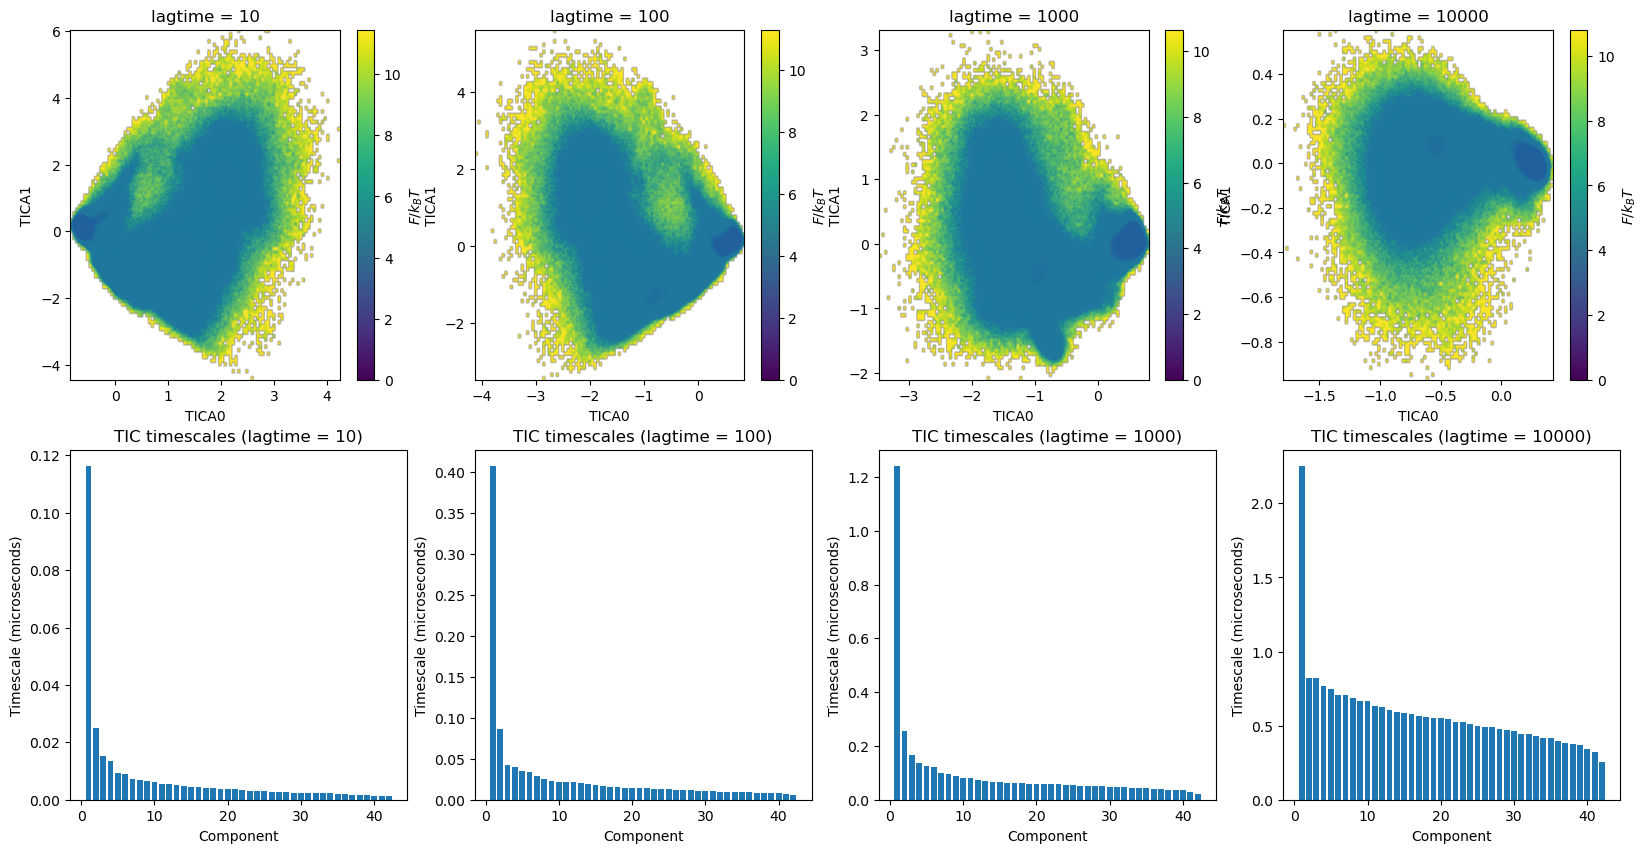

In [40]:
lagtime_array = [10, 100, 1000, 10000] 

fig, axes = plt.subplots(2, len(lagtime_array), figsize=(20, 10))

for lagtime in lagtime_array:
    ticamodel = TICA(lagtime=lagtime, dim=5)
    ticamodel.fit(X)
    tica_traj = ticamodel.transform(X)
    plot_free_energy_projection(tica_traj, 0, 1, ax = axes[0, lagtime_array.index(lagtime)], axlabel = "TICA", axtitle = f"lagtime = {lagtime}")


    # Plot timescales
    timescales = ticamodel.model.timescales()
    axes[1, lagtime_array.index(lagtime)].bar(range(1, len(timescales) + 1), timescales * time_step_micros)
    axes[1, lagtime_array.index(lagtime)].set_xlabel("Component")
    axes[1, lagtime_array.index(lagtime)].set_ylabel("Timescale (microseconds)")
    axes[1, lagtime_array.index(lagtime)].set_title(f"TIC timescales (lagtime = {lagtime})")




In [36]:
# timescale = - lagtime / log(singular_value)

print(ticamodel.model.timescales()[0] * time_step_micros)
print((- ticamodel.model.lagtime / np.log(ticamodel.model.singular_values[0])) * time_step_micros)

2.24913877843119
2.24913877843119


### different normalizations

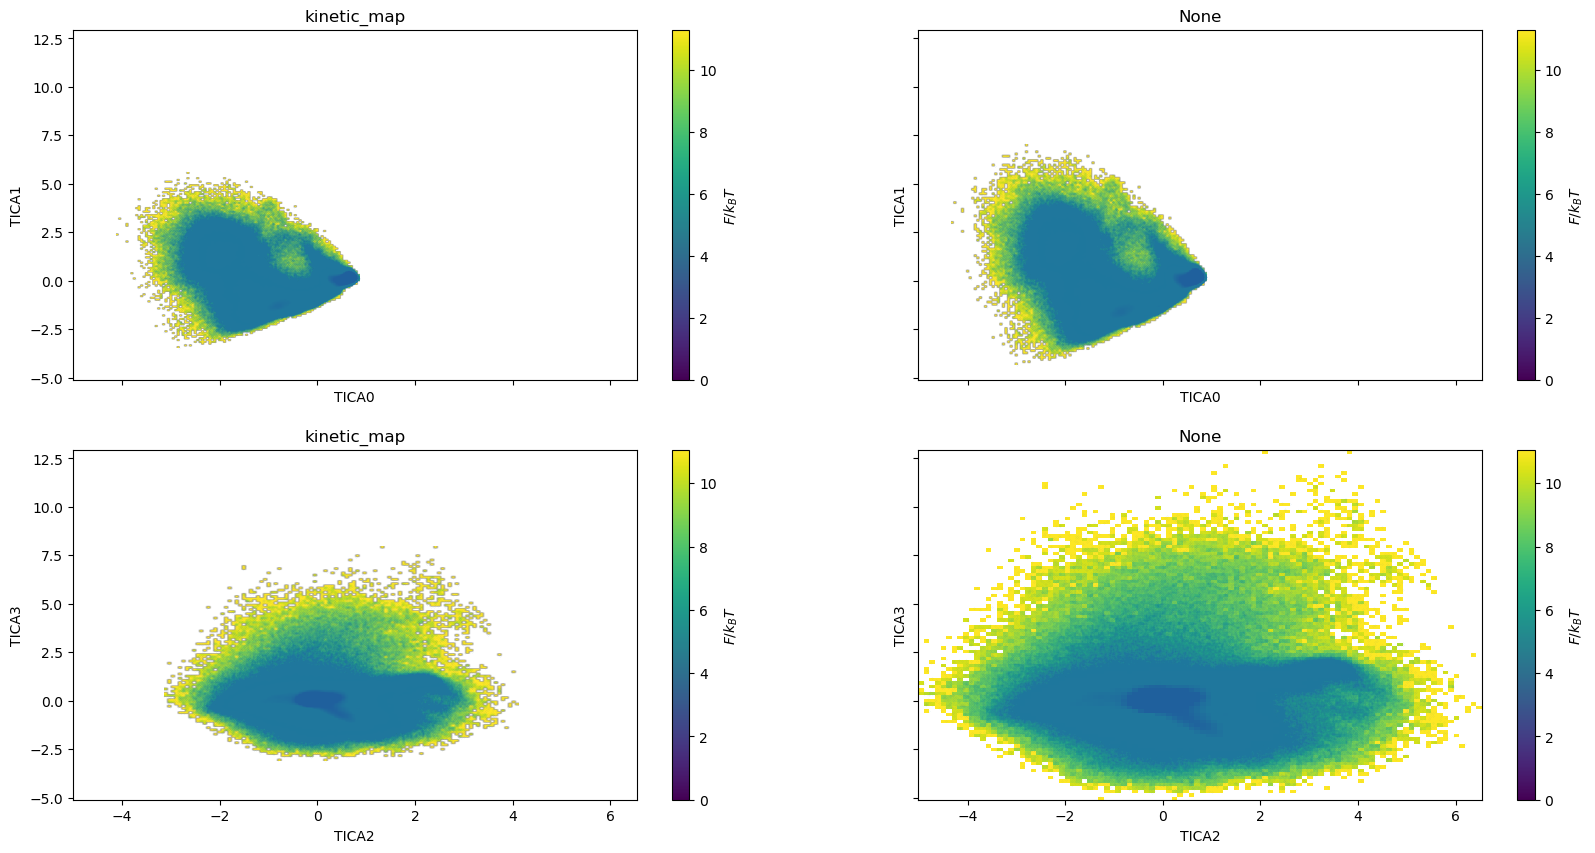

In [52]:
normalization_choices = ["kinetic_map", None]
fig, axes = plt.subplots(2, len(normalization_choices), figsize=(20, 10), sharey=True, sharex=True)

for ax in axes.flatten():
    ax.axis("equal")

tica = TICA(lagtime=100, dim=5)

for scaling_choice in normalization_choices:
    tica.scaling = scaling_choice
    ticamodel = tica.fit(X)
    tica_traj = ticamodel.transform(X)
    plot_free_energy_projection(tica_traj, 0, 1, ax = axes[0, normalization_choices.index(scaling_choice)], axlabel = "TICA", axtitle = f"{ticamodel.scaling}")
    plot_free_energy_projection(tica_traj, 2, 3, ax = axes[1, normalization_choices.index(scaling_choice)], axlabel = "TICA", axtitle = f"{ticamodel.scaling}")

---
#### tICA vs PCA - visualization

<Axes: xlabel='tIC1', ylabel='tIC2'>

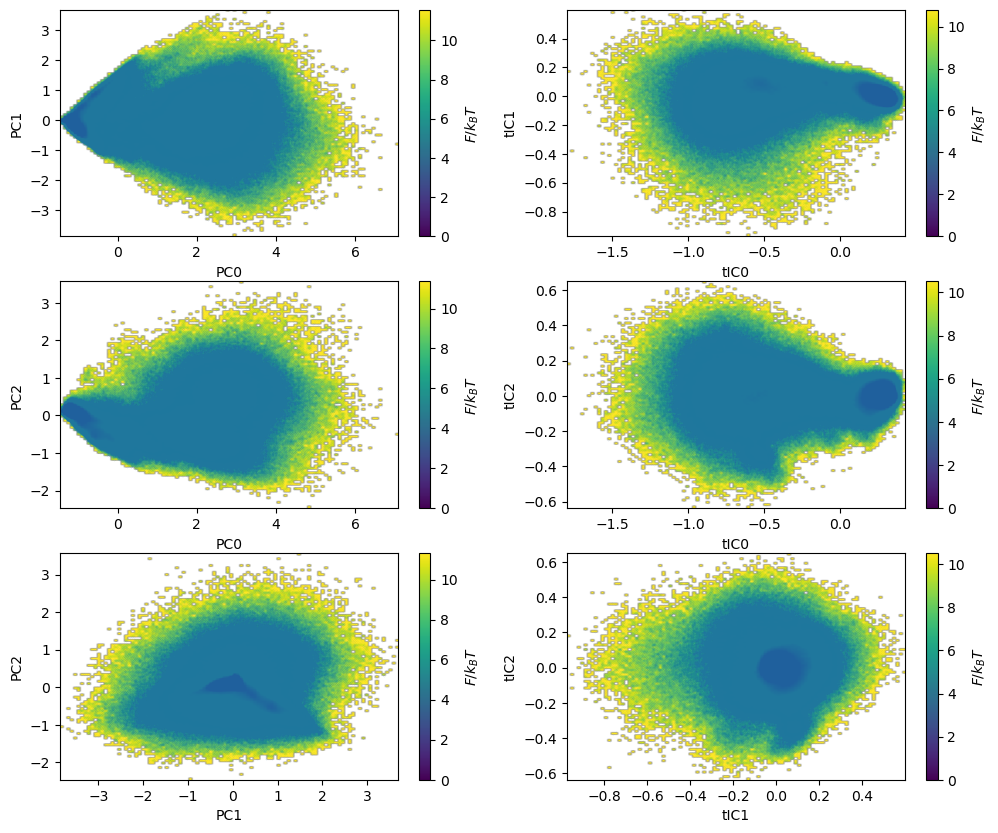

In [27]:
fig, axs = plt.subplots(3, 2, figsize=(12, 10))

plot_free_energy_projection(pca_traj, 0, 1, ax = axs[0, 0], axlabel = "PC")
plot_free_energy_projection(tica_traj, 0, 1, ax = axs[0, 1], axlabel = "tIC")


plot_free_energy_projection(pca_traj, 0, 2, ax = axs[1, 0], axlabel = "PC")
plot_free_energy_projection(tica_traj, 0, 2, ax = axs[1, 1], axlabel = "tIC")


plot_free_energy_projection(pca_traj, 1, 2, ax = axs[2, 0], axlabel = "PC")
plot_free_energy_projection(tica_traj, 1, 2, ax = axs[2, 1], axlabel = "tIC")

tICA eigenvalues